<a href="https://colab.research.google.com/github/abhishekpm239-svg/song-recomendation/blob/main/song_recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly
from sklearn.preprocessing import StandardScaler
from scipy.spatial import distance
import copy
import warnings
warnings.filterwarnings("ignore")
plotly.offline.init_notebook_mode (connected = True)

In [ ]:
data=pd.read_csv('/content/genres_v2.csv', on_bad_lines='skip')

In [ ]:
data.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.0134,0.0556,0.389,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.401,0.0,0.1180,0.124,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.85,0.893,5,-4.783,1,0.0623,0.0138,4.14e-06,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.0,0.1140,0.175,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.217,0.0,0.1660,0.591,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN


In [ ]:
data.tail()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
64987,0.528,0.693,4,-5.148,1,0.0304,0.0315,0.00034500000000000004,0.1210,0.394,...,46bXU7Sgj7104ZoXxzz9tM,spotify:track:46bXU7Sgj7104ZoXxzz9tM,https://api.spotify.com/v1/tracks/46bXU7Sgj710...,https://api.spotify.com/v1/audio-analysis/46bX...,269208.0,4,hardstyle,NaN,20995.0,Euphoric Hardstyle
64988,0.517,0.768,0,-7.922,0,0.0479,0.0225,1.82e-05,0.2050,0.383,...,0he2ViGMUO3ajKTxLOfWVT,spotify:track:0he2ViGMUO3ajKTxLOfWVT,https://api.spotify.com/v1/tracks/0he2ViGMUO3a...,https://api.spotify.com/v1/audio-analysis/0he2...,210112.0,4,hardstyle,NaN,20996.0,Greatest Hardstyle Playlist
64989,0.361,0.821,8,-3.102,1,0.0505,0.026,0.000242,0.3850,0.124,...,72DAt9Lbpy9EUS29OzQLob,spotify:track:72DAt9Lbpy9EUS29OzQLob,https://api.spotify.com/v1/tracks/72DAt9Lbpy9E...,https://api.spotify.com/v1/audio-analysis/72DA...,234823.0,4,hardstyle,NaN,20997.0,Best of Hardstyle 2020
64990,0.477,0.921,6,-4.777,0,0.0392,0.000551,0.0296,0.0575,0.488,...,6HXgExFVuE1c3cq9QjFCcU,spotify:track:6HXgExFVuE1c3cq9QjFCcU,https://api.spotify.com/v1/tracks/6HXgExFVuE1c...,https://api.spotify.com/v1/audio-analysis/6HXg...,323200.0,4,hardstyle,NaN,20998.0,Euphoric Hardstyle
64991,0.529,0.945,9,-5.862,1,0.0615,0.00189,5.45e-05,0.4140,0.134,...,6MAAMZImxcvYhRnxDLTufD,spotify:track:6MAAMZImxcvYhRnxDLTufD,https://api.spotify.com/v1/tracks/6MAAMZImxcvY...,https://api.spotify.com/v1/audio-analysis/6MAA...,162161.0,4,hardstyle,NaN,20999.0,Best of Hardstyle 2020


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64992 entries, 0 to 64991
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      64992 non-null  object 
 1   energy            64992 non-null  object 
 2   key               64992 non-null  int64  
 3   loudness          64992 non-null  float64
 4   mode              64992 non-null  object 
 5   speechiness       64990 non-null  float64
 6   acousticness      64991 non-null  object 
 7   instrumentalness  64991 non-null  object 
 8   liveness          64989 non-null  float64
 9   valence           64989 non-null  object 
 10  tempo             64989 non-null  object 
 11  type              64989 non-null  object 
 12  id                64989 non-null  object 
 13  uri               64989 non-null  object 
 14  track_href        64988 non-null  object 
 15  analysis_url      64989 non-null  object 
 16  duration_ms       64988 non-null  object

In [ ]:
cols=list(data.columns[11:])
del cols[7]

In [ ]:
df=copy.deepcopy(data)
df.drop(columns=cols,inplace=True)

In [ ]:
sns.set(style="ticks", context="talk")
plt.style.use("dark_background")

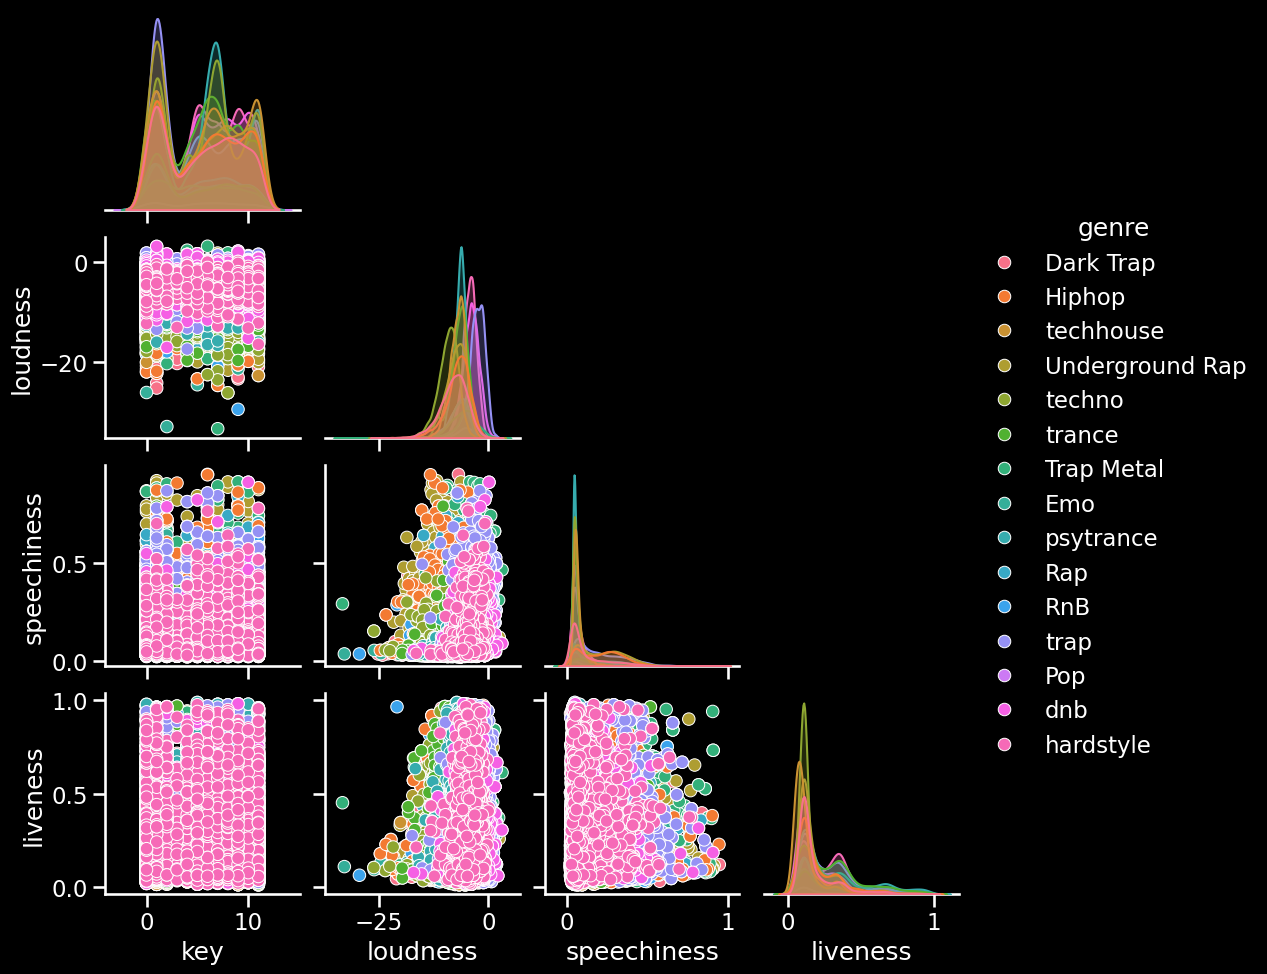

In [ ]:
sns.pairplot(df,corner=True,hue='genre')

In [ ]:
px.box(data_frame=data,y='duration_ms',color='genre')

In [ ]:
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
columns_to_convert = [
    'danceability', 'energy', 'mode', 'acousticness', 'instrumentalness',
    'valence', 'tempo', 'duration_ms', 'time_signature'
]

for col in columns_to_convert:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

numeric_data = data.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

x = list(correlation_matrix.columns)
y = list(correlation_matrix.index)
values = np.array(correlation_matrix.values)

fig = go.Figure(data=go.Heatmap(
    z=values,
    x=x,
    y=y,
    hoverongaps=False
))
fig.show()


In [ ]:
data=data.dropna(subset=['song_name'])

In [ ]:
df=data[data.columns[:11]]
df['genre']=data['genre']
df['time_signature']=data['time_signature']
df['duration_ms']=data['duration_ms']
df['song_name']=data['song_name']

In [ ]:
x=df[df.drop(columns=['song_name','genre']).columns].values
scaler = StandardScaler().fit(x)
X_scaled = scaler.transform(x)
df[df.drop(columns=['song_name','genre']).columns]=X_scaled

In [ ]:
def find_word(word,words):
    t=[]
    count=0
    if word[-1]==' ':
        word=word[:-1]
    for i in words:
        if word.lower() in i.lower():
            t.append([len(word)/len(i),count])
        else:
            t.append([0,count])
        count+=1
    t.sort(reverse=True)
    return words[t[0][1]]

In [ ]:
def make_matrix(data_for_recs, song, number):
    current_df = data_for_recs.copy()
    current_df.drop_duplicates(inplace=True)

    songs = current_df['song_name'].values
    best_song_name = find_word(song, songs)
    print('The song closest to your search is :', best_song_name)

    # Get the reference song's row from the full (deduplicated) DataFrame
    reference_song_row = current_df[current_df['song_name'] == best_song_name]

    if reference_song_row.empty:
        print(f"Error: Song '{best_song_name}' not found in the dataset after deduplication.")
        return

    # Extract genre of the reference song
    genre = reference_song_row['genre'].values[0]

    # Extract features for the reference song (x)
    x = reference_song_row.drop(columns=['genre', 'song_name']).values
    # Ensure x is a 1D array
    if x.ndim == 2 and x.shape[0] > 0:
        x = x[0]
    else:
        print(f"Error: Could not extract a valid 1D feature vector for song '{best_song_name}'.")
        return

    # Filter the recommendation pool by genre and exclude the reference song itself
    recommendation_pool_df = current_df[
        (current_df['genre'] == genre) & (current_df['song_name'] != best_song_name)
    ].copy()

    if recommendation_pool_df.empty:
        print(f"No other songs found in the genre '{genre}' for recommendations.")
        return

    song_names_for_recs = recommendation_pool_df['song_name'].values

    # Prepare features for distance calculation from the recommendation pool
    recommendation_pool_features = recommendation_pool_df.drop(columns=['genre', 'song_name'])
    recommendation_pool_features = recommendation_pool_features.fillna(recommendation_pool_features.mean())

    distances = []
    # Double-check if x is still valid before loop, though previous checks should prevent this
    if x.size == 0:
        print(f"Error: Reference song features for '{best_song_name}' are empty. Cannot calculate distances.")
        return

    for idx, row_features in enumerate(recommendation_pool_features.values):
        distances.append([distance.euclidean(x, row_features), idx])

    distances.sort()

    print("\nRecommended songs:")
    for i in range(min(number, len(distances))):
        print(song_names_for_recs[distances[i][1]])

In [ ]:
a=input('Please enter The name of the song :')
b=int(input('Please enter the number of recommendations you want: '))
make_matrix(df,a,b)

Please enter The name of the song :Symbiote
Please enter the number of recommendations you want: 2
The song closest to your search is : Symbiote

Recommended songs:
Holy Ghost
Dejection


In [ ]:
def make_matrix_cosine(data,song,number):
    df=pd.DataFrame()
    data.drop_duplicates(inplace=True)
    songs=data['song_name'].values
    best=find_word(song,songs)
    print('The song closest to your search is :',best)
    genre=data[data['song_name']==best]['genre'].values[0]
    df=data[data['genre']==genre]
    x=df[df['song_name']==best].drop(columns=['genre','song_name']).values
    # Ensure x is a 1D array
    if x.ndim == 2 and x.shape[0] > 0:
        x = x[0]
    song_names=df['song_name'].values
    df.drop(columns=['genre','song_name'],inplace=True)
    df=df.fillna(df.mean())
    p=[]
    count=0
    for i in df.values:
        p.append([distance.cosine(x,i),count])
        count+=1
    p.sort()
    for i in range(1,number+1):
        print(song_names[p[i][1]])

In [ ]:
c=input('Please enter The name of the song :')
d=int(input('Please enter the number of recommendations you want: '))
make_matrix_cosine(df,c,d)


Please enter The name of the song :Symbiote
Please enter the number of recommendations you want: 2
The song closest to your search is : Symbiote
Memoirs Of A Gorilla
Holy Ghost


In [ ]:
def make_matrix_correlation(data_for_recs, song, number):
    current_df = data_for_recs.copy()
    current_df.drop_duplicates(inplace=True)

    songs = current_df['song_name'].values
    best_song_name = find_word(song, songs)
    print('The song closest to your search is :', best_song_name)

    # Get the reference song's row from the full (deduplicated) DataFrame
    reference_song_row = current_df[current_df['song_name'] == best_song_name]

    if reference_song_row.empty:
        print(f"Error: Song '{best_song_name}' not found in the dataset after deduplication.")
        return

    # Extract genre of the reference song
    genre = reference_song_row['genre'].values[0]

    # Extract features for the reference song (x)
    x = reference_song_row.drop(columns=['genre', 'song_name']).values
    # Ensure x is a 1D array
    if x.ndim == 2 and x.shape[0] > 0:
        x = x[0]
    else:
        print(f"Error: Could not extract a valid 1D feature vector for song '{best_song_name}'.")
        return

    # Filter the recommendation pool by genre and exclude the reference song itself
    recommendation_pool_df = current_df[
        (current_df['genre'] == genre) & (current_df['song_name'] != best_song_name)
    ].copy()

    if recommendation_pool_df.empty:
        print(f"No other songs found in the genre '{genre}' for recommendations.")
        return

    song_names_for_recs = recommendation_pool_df['song_name'].values

    # Prepare features for distance calculation from the recommendation pool
    recommendation_pool_features = recommendation_pool_df.drop(columns=['genre', 'song_name'])
    recommendation_pool_features = recommendation_pool_features.fillna(recommendation_pool_features.mean())

    distances = []
    # Double-check if x is still valid before loop, though previous checks should prevent this
    if x.size == 0:
        print(f"Error: Reference song features for '{best_song_name}' are empty. Cannot calculate distances.")
        return

    for idx, row_features in enumerate(recommendation_pool_features.values):
        distances.append([distance.correlation(x, row_features), idx])

    distances.sort()

    print("\nRecommended songs:")
    for i in range(min(number, len(distances))):
        print(song_names_for_recs[distances[i][1]])

In [ ]:
e=input('Please enter The name of the song :')
f=int(input('Please enter the number of recommendations you want: '))
make_matrix_correlation(df,e,f)

Please enter The name of the song :Symbiote
Please enter the number of recommendations you want: 2
The song closest to your search is : Symbiote

Recommended songs:
Memoirs Of A Gorilla
MFG (feat. Ramirez)


In [ ]:
g = input('Please enter The name of the song: ')
h = int(input('Please enter the number of recommendations you want (e.g., 5): '))
make_matrix_correlation(df, g, h)

Please enter The name of the song: Symbiote
Please enter the number of recommendations you want (e.g., 5): 3
The song closest to your search is : Symbiote

Recommended songs:
Memoirs Of A Gorilla
MFG (feat. Ramirez)
Memoirs of a Gorilla
